# Import Libraries

### Import required libraries for Analysis

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

# Load Dataset

In [5]:
df = pd.read_csv("retail_large_dataset.csv")

### Displaying First 5 Rows of Dataset

In [6]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [7]:
df.shape

(100000, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          100000 non-null  object        
 1   age                  100000 non-null  int64         
 2   gender               100000 non-null  object        
 3   city                 100000 non-null  object        
 4   state                100000 non-null  object        
 5   customer_segment     100000 non-null  object        
 6   order_id             100000 non-null  object        
 7   order_date           100000 non-null  datetime64[ns]
 8   product_category     100000 non-null  object        
 9   product_subcategory  100000 non-null  object        
 10  product_price        100000 non-null  int64         
 11  quantity             100000 non-null  int64         
 12  discount_percentage  100000 non-null  int64         
 13  final_price    

In [11]:
df.describe()

,age,order_date,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,2024-06-29 02:48:38.304000,30164.526720,2.501790,15.009890,64165.723382,5.505540
min,18.000000,2023-01-01 00:00:00,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,2023-09-30 00:00:00,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,2024-06-28 00:00:00,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,2025-03-30 00:00:00,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,2025-12-30 00:00:00,59998.000000,4.000000,30.000000,239980.000000,10.000000
std,13.852439,NaN,17139.679807,1.120058,8.953296,49969.280150,2.872868


# Missing Values

In [12]:
df.isnull().sum()

customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64

# Mean, Median and Mode

In [13]:
df['product_price'].mean()

np.float64(30164.52672)

In [14]:
df['product_price'].median()

30148.0

In [15]:
df['product_price'].std()

17139.679807208286

# Univariate Analysis

### Product Price Distribution

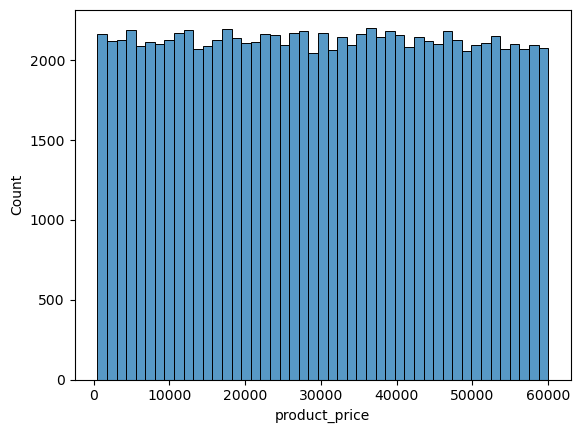

In [16]:
sns.histplot(df['product_price'])
plt.show()

### Product Category

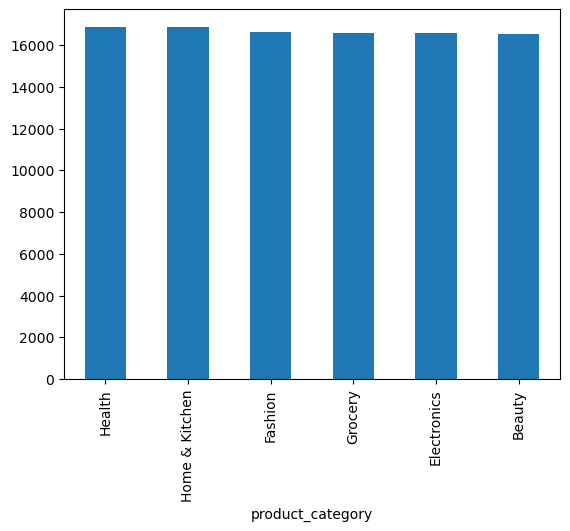

In [17]:
df['product_category'].value_counts().plot (kind='bar')
plt.show()

### Return Status

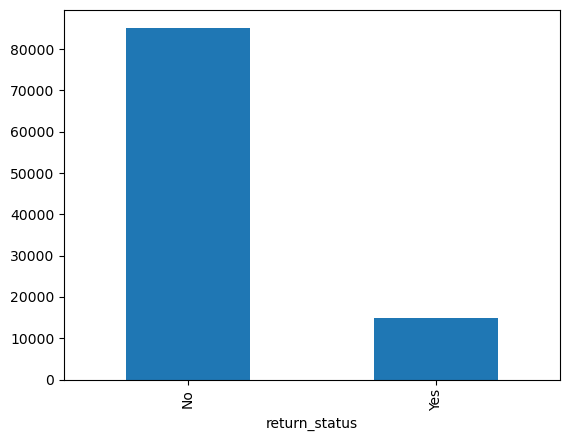

In [18]:
df['return_status'].value_counts().plot(kind='bar')
plt.show()

### Outlier Check by using IQR Method

In [19]:
Q1 = df['final_price'].quantile(0.25)
Q3 = df['final_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['final_price'] < lower_bound) | (df['final_price'] > upper_bound)]

print("Total Outliers:", len(outliers))

Lower Bound: -79306.60499999998
Upper Bound: 198057.675
Total Outliers: 1335


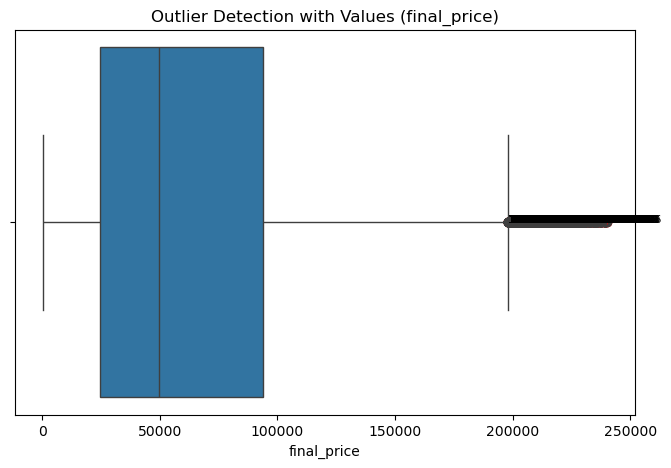

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['final_price'])
outliers = df[(df['final_price'] < lower_bound) | (df['final_price'] > upper_bound)]
plt.scatter(outliers['final_price'], [0]*len(outliers), color='red')
for val in outliers['final_price']:
    plt.text(val, 0, str(val), fontsize=8)
plt.title("Outlier Detection with Values (final_price)")
plt.show()

# Bivariate Analysis

### Product Price & Final Price

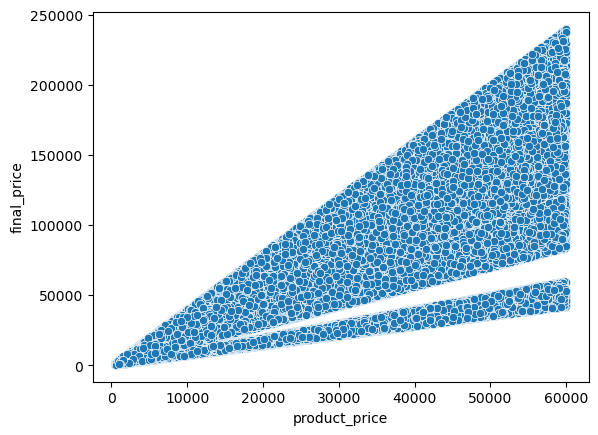

In [21]:
sns.scatterplot(x='product_price', y='final_price', data=df)
plt.show()

### Shipping Types and Delivery Days

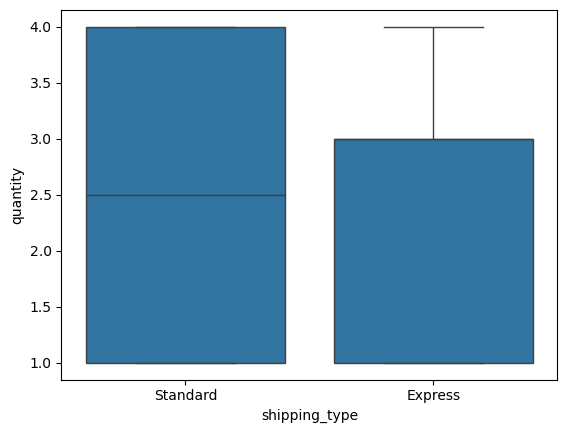

In [22]:
sns.boxplot(x='shipping_type', y='quantity', data=df)
plt.show()

### Customer Segment & Spending

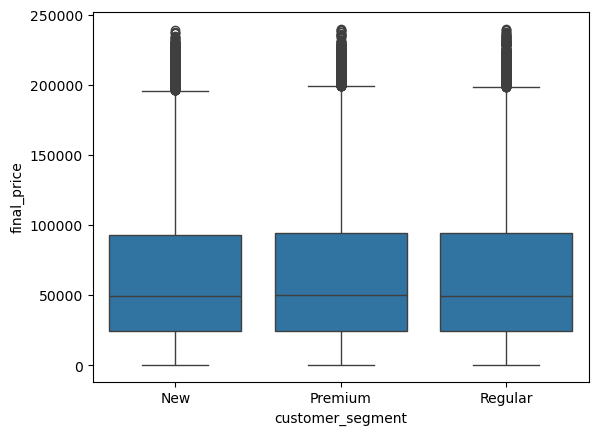

In [23]:
sns.boxplot(x='customer_segment', y='final_price', data=df)
plt.show()

# Multivariate Analysis

### Time Based Analysis

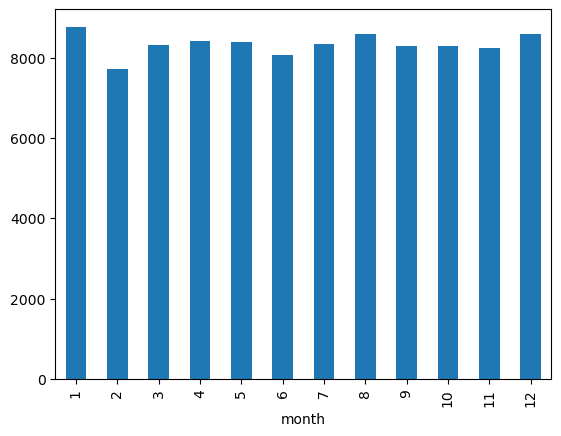

In [24]:
df['month'] = df['order_date'].dt.month

df['month'].value_counts().sort_index().plot(kind='bar')
plt.show()

### Category, Quantity and Final Price

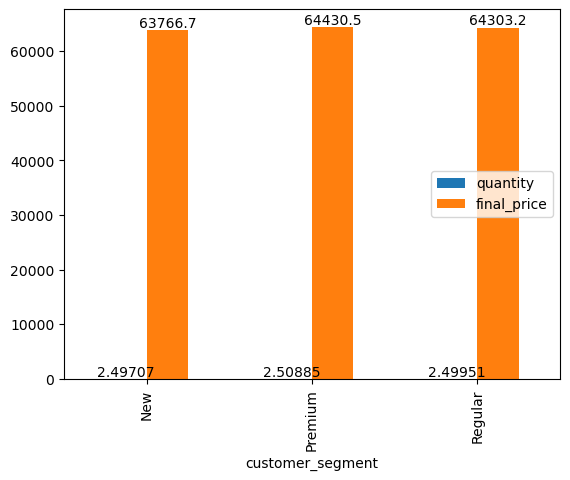

In [25]:
ax = df.groupby('customer_segment')[['quantity','final_price']].mean().plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Customer Segment Analysis

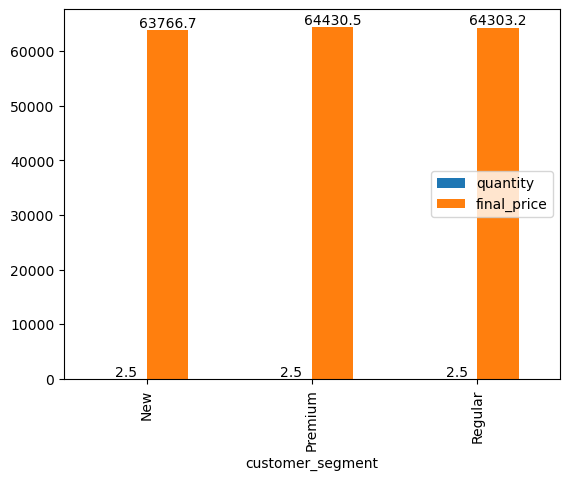

In [26]:
seg_data = df.groupby('customer_segment')[['quantity','final_price']].mean()

ax = seg_data.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.show()

### Skewness

In [27]:
print(df['product_price'].skew())
print(df['final_price'].skew())

0.0032490380525730346
0.9347465430576104


### Kurtosis

In [28]:
print(df['product_price'].kurt())
print(df['final_price'].kurt())

-1.1951055614421242
0.16904721381804322


# Correlation Matrix

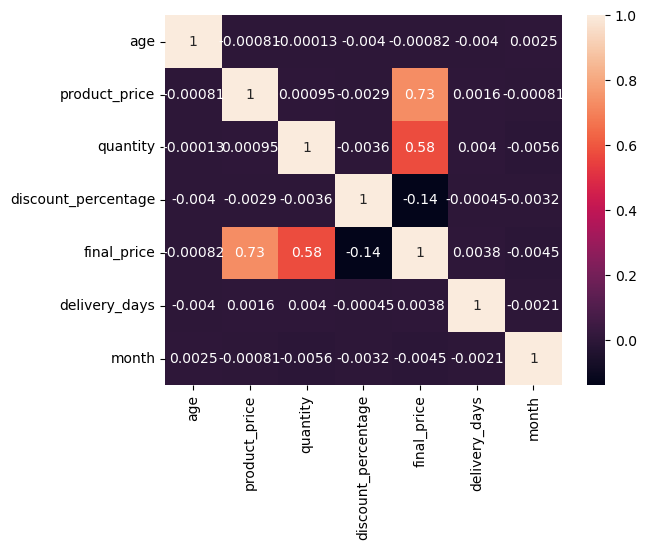

In [29]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()